In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler


# Cleaning Data
#### วิธีทำ
1. Load data
2. Data Reshaping (Pivot Table)
3.  Return Transformation (Daily Log Returns)
4.  Handling Missing Values (ตัดหุ้นที่มีค่าว่างออก)
5.  Standardization & Transpose (ปรับสเกลและสลับมิติให้หุ้นเป็น Samples พร้อมเข้าโมเดล)

In [12]:
# step 1
df = pd.read_csv('NASDAQ-100/NASDAQ_100_Data_From_2010.csv', sep='\t')
df['Date'] = pd.to_datetime(df['Date'])

# step 2
price_matrix = df.pivot(index='Date', columns='Name', values='Adj Close')

#step 3 
returns_matrix = np.log(price_matrix / price_matrix.shift(1)).iloc[1:]

# step 4 
clean_returns = returns_matrix.dropna(axis=1)

# step 5 
scaler = StandardScaler()
X = scaler.fit_transform(clean_returns).T
stock_names = clean_returns.columns.tolist()
print(stock_names)

['AAPL', 'ADBE', 'ADI', 'ADP', 'ADSK', 'AEP', 'ALGN', 'AMAT', 'AMD', 'AMGN', 'AMZN', 'ANSS', 'ASML', 'ATVI', 'AVGO', 'BIDU', 'BIIB', 'BKNG', 'CDNS', 'CERN', 'CHKP', 'CMCSA', 'COST', 'CPRT', 'CSCO', 'CSX', 'CTAS', 'CTSH', 'DLTR', 'DXCM', 'EA', 'EBAY', 'EXC', 'FAST', 'FISV', 'GILD', 'GOOG', 'GOOGL', 'HON', 'IDXX', 'ILMN', 'INCY', 'INTC', 'INTU', 'ISRG', 'KDP', 'KLAC', 'LRCX', 'LULU', 'MAR', 'MCHP', 'MDLZ', 'MELI', 'MNST', 'MRVL', 'MSFT', 'MTCH', 'MU', 'NFLX', 'NTES', 'NVDA', 'ORLY', 'PAYX', 'PCAR', 'PEP', 'QCOM', 'REGN', 'ROST', 'SBUX', 'SGEN', 'SIRI', 'SNPS', 'SWKS', 'TCOM', 'TMUS', 'TXN', 'VRSK', 'VRSN', 'VRTX', 'WBA', 'XEL', 'XLNX']


## Hierarchical Clustering

In [13]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster import hierarchy
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score, davies_bouldin_score

## คำนวณ Correlation แปลงเป็น Distance Metrix

In [32]:
corr = returns.corr()
dist = np.sqrt(np.maximum(0, 2 * (1 - corr)))

### Train Model 
#### คำอธิบาย
1. linkage='complete' คำนวณระยะห่างระหว่างกลุ่มจากคู่ที่อยู่ไกลกันที่สุด (Maximum distance) ทำให้สร้างกลุ่มที่มีขนาดกะทัดรัด
2. metric='precomputed' โมเดลจะไม่คำนวณระยะห่าง (Distance) หรือความคล้าย (Similarity) ให้คุณใหม่ แต่คุณต้องป้อน Distance Matrix (เมทริกซ์ระยะห่าง) ที่คำนวณเสร็จเรียบร้อยแล้วเข้าไปในตัวแปร dist โดยตรง
3. metric='euclidean' โมเดลจะนำจุดแต่ละจุดไปคำนวณหาระยะห่างระหว่างกันให้เอง

In [45]:
agg_model = AgglomerativeClustering(n_clusters=6, metric='precomputed', linkage='complete')
agg_labels = agg_model.fit_predict(dist)

### วัดคุณภาพโครงสร้างกลุ่มด้วย Unsupervised Metrics
1. Silhouette Score
   - -1 ถึง 1: ยิ่งใกล้ 1 กลุ่มยิ่งจับตัวแน่นและแยกกันชัดเจน
2. Davies-Bouldin Index
   - ยิ่งใกล้ 0 ยิ่งดี คลัสเตอร์ซ้อนทับกันน้อย

#### การใช้งาน 
- Silhouette Score: วัดว่าหุ้นในกลุ่มชิดกันเอง และอยู่ห่างจากกลุ่มอื่นมากแค่ไหน
- Davies-Bouldin Index: วัดความแออัดและการซ้ำซ้อนกันระหว่างแต่ละคลัสเตอร์

In [46]:
sil_score = silhouette_score(X, agg_labels)
print(sil_score)

db_score = davies_bouldin_score(X, agg_labels)
print(db_score)

0.06126953742634967
2.4741828933010432


### การสร้าง Dendrogram ด้วย scipy เพื่อดูแผนผังการรวมกลุ่ม

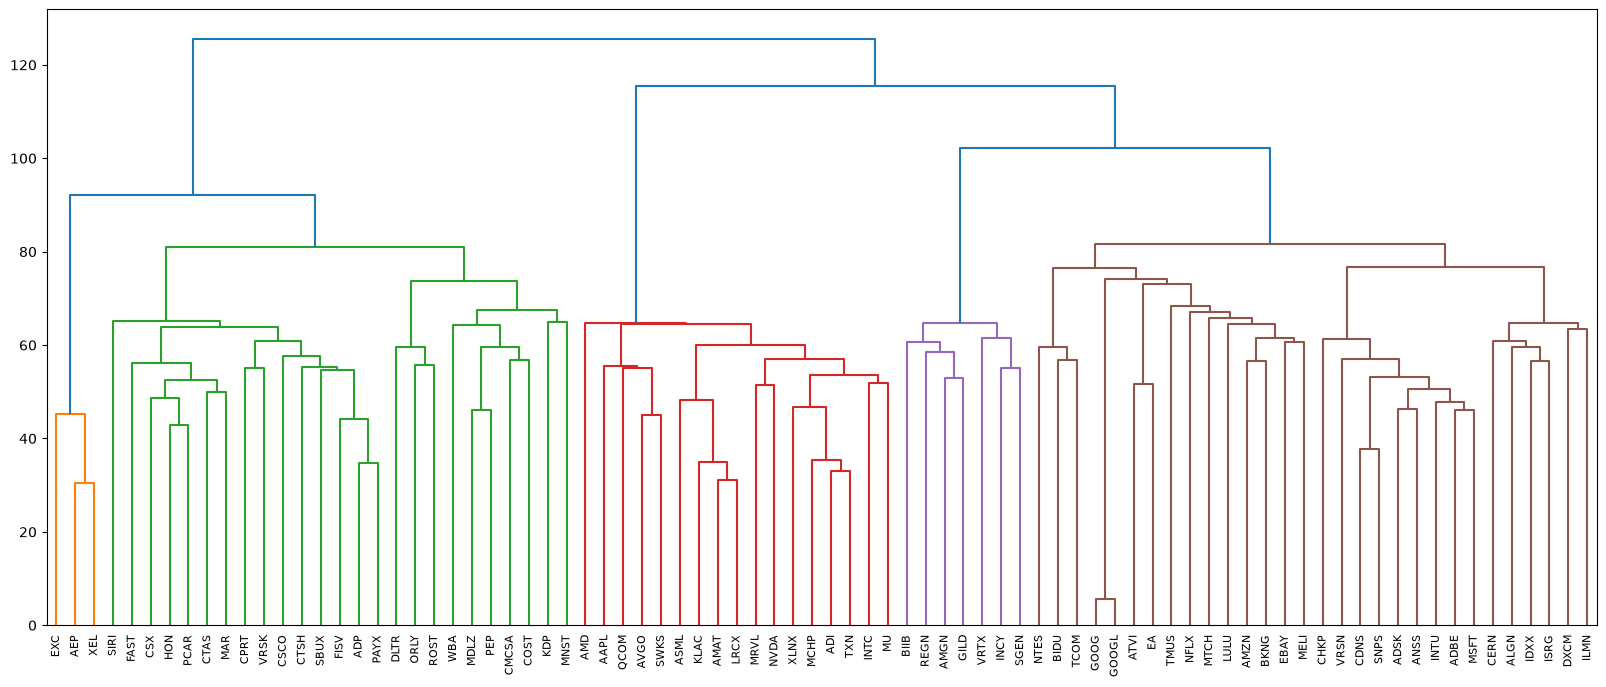

In [47]:
plt.figure(figsize=(20, 8))
dendrogram = hierarchy.dendrogram(hierarchy.linkage(X, method='ward'), labels=stock_name, orientation='top', leaf_font_size=8)

## แสดงผลรายชื่อหุ้นในแต่ละ Cluster

In [48]:
cluster = pd.Series(
    agg_model.labels_,
    index=returns.columns,
    name="Cluster",
)
for c in range(6):
    stock_in_c = cluster[cluster == c].index.tolist()
    print(f"--- Cluster {c + 1} ({len(stock_in_c)} หุ้น) ---")
    print(", ".join(stock_in_c))

--- Cluster 1 (55 หุ้น) ---
AAPL, ADBE, ADI, ADP, ADSK, ALGN, AMAT, AMD, AMZN, ANSS, ASML, ATVI, AVGO, BKNG, CDNS, CERN, CHKP, CMCSA, CPRT, CSCO, CSX, CTSH, DXCM, EA, EBAY, FAST, FISV, GOOG, GOOGL, HON, IDXX, ILMN, INTC, INTU, ISRG, KLAC, LRCX, MCHP, MELI, MRVL, MSFT, MTCH, MU, NVDA, PAYX, PCAR, QCOM, SIRI, SNPS, SWKS, TMUS, TXN, VRSK, VRSN, XLNX
--- Cluster 2 (9 หุ้น) ---
CTAS, DLTR, KDP, LULU, MAR, MNST, ORLY, ROST, SBUX
--- Cluster 3 (7 หุ้น) ---
AMGN, BIIB, GILD, INCY, REGN, SGEN, VRTX
--- Cluster 4 (7 หุ้น) ---
AEP, COST, EXC, MDLZ, PEP, WBA, XEL
--- Cluster 5 (3 หุ้น) ---
BIDU, NTES, TCOM
--- Cluster 6 (1 หุ้น) ---
NFLX
